# Archelec — Topic Modeling of French Campaign Manifestos (1981–1993)

# Notebook 02 - Main contributions, state of the art, experiments and interpretation

## Objective

This notebook applies and compares three topic modeling approaches — **LDA**, **NMF**, and **BERTopic** — to the preprocessed Archelec corpus (~12,500 campaign manifestos, 1981–1993), then crosses the extracted topics with political metadata (family, year, gender, profession). The goal of this project is to back up with data potential misconceptions, such as thematic propensity by party, specilization by party, correlation between topic and metadata...

By crossing data over parties, themes and time, we hope to observe meaningful results, from which we can derive interesting interpretations.

Eventually, it also includes a supervised classification experiment to assess how distinguishable political families are from text alone.

## Background

Topic modeling is a well-established family of unsupervised methods for discovering latent thematic structure in document collections. Topic modeling is a class of unsupervised machine learning methods used to automatically discover the main themes (or topics) present in a large collection of documents. Instead of relying on predefined labels, these models analyze patterns of word co-occurrence across documents to infer groups of words that tend to appear together. Each group represents a latent topic, interpreted as a semantic theme in the corpus.

About the models, **LDA** (Blei et al., 2003) remains the standard probabilistic baseline, modeling each document as a mixture of topics drawn from Dirichlet priors. **NMF** (Lee & Seung, 1999), applied to a TF-IDF matrix, offers a non-probabilistic alternative that typically produces sharper, more localized topics. More recently, **BERTopic** (Grootendorst, 2022) leverages pre-trained transformer embeddings, UMAP dimensionality reduction, and HDBSCAN clustering to capture semantic similarity beyond bag-of-words co-occurrence patterns.

In the specific domain of political text analysis, Grimmer & Stewart (2013) provide a comprehensive framework for applying NLP methods to political corpora, emphasizing that unsupervised models require careful human validation. Topic coherence metrics — particularly c_v (Röder et al., 2015), which correlates best with human judgments — are now the standard for model selection and comparison.

Applied to electoral discourse, topic modeling has been used to study party positioning, issue salience, and ideological shifts over time. The Archelec corpus (Gaultier-Voituriez, Sciences Po) offers a unique opportunity to study these dynamics at the candidate level rather than the party level, across a politically turbulent period (the Mitterrand era).

## Model choice and justification

We compare the three methods taught in the course, each representing a distinct paradigm:

| Method | Input | Rationale |
|--------|-------|-----------|
| **LDA** (gensim) | BoW counts | Probabilistic baseline; standard reference in the literature |
| **NMF** (scikit-learn) | TF-IDF | Deterministic factorisation; often produces more interpretable topics on political text |
| **BERTopic** (sentence-transformers) | SBERT embeddings | Captures semantic structure beyond lexical co-occurrence; detects document-level patterns invisible to BoW methods |

All three are evaluated using **c_v** and **u_mass** coherence (Röder et al., 2015) on the same lemmatised vocabulary, enabling direct comparison. A supplementary **logistic regression classifier** predicts political family from TF-IDF features, providing an independent validation of how well topics align with political divisions.

In [ ]:
seed = 42
import spacy
nlp = spacy.load("fr_core_news_md", disable=["ner", "parser"])

CUSTOM_STOPWORDS = {
    'être', 'avoir', 'faire', 'plus', 'tout', 'aussi', 'très', 'bien',
    'encore', 'déjà', 'toujours', 'tant', 'rien', 'autre', 'même',
    'non', 'oui', 'où', 'comme', 'sans', 'avec', 'dans', 'pour',
    'par', 'sur', 'entre', 'vers', 'sous', 'depuis', 'après', 'avant',
    'contre', 'chez', 'car', 'donc', 'cela', 'celui', 'cette', 'ceux',
    'france', 'français', 'française', 'pays', 'national', 'politique',
    'candidat', 'élection', 'vote', 'voter', 'circonscription', 'gauche', 'droite', 'centre', 'communiste', 'socialiste', 'écologiste',
    'falloir', 'pouvoir', 'devoir', 'savoir', 'vouloir', 'venir', 'aller', 'voir', 'prendre',
    'député', 'janvier', 'février', 'mars', 'avril', 'mai', 'juin', 'juillet', 'août', 'septembre', 'octobre', 'novembre', 'décembre',
}

In [8]:
# !pip install -r requirements.txt
 
import os
import re
import glob
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter

sns.set_style("whitegrid")
plt.rcParams['figure.figsize'] = (12, 6)
plt.rcParams['font.size'] = 12

print("Imports OK")

df = pd.read_csv('data/archelec_eda.csv')
df.head()

Imports OK


,id,date,subject,title,contexte-election,contexte-tour,cote,departement,departement-nom,departement-insee,...,suppleant-liste,suppleant-decorations,annee,text_raw,text_clean,n_words_raw,n_words_clean,famille,tokens,n_tokens
0,EL134_L_1981_06_001_01_1_PF_01,1981-06-14,France;Assemblée Nationale;Ve République;Élect...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,ELECTIONS LEGISLATIVES - 14 JUIN 1981 AIN 1e C...,Micheline ANTONUCCI POUR QUE ÇA DURE ... La vi...,552,527,Far left,"['micheline', 'antonucci', 'dur', 'victoire', ...",185
1,EL134_L_1981_06_001_01_1_PF_02,1981-06-14,Élections législatives;Ve République;Assemblée...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union de la gauche,non,1981,Sciences Po / fonds CEVIPOF\nELECTIONS LÉGISLA...,"ELECTIONS LÉGISLATIVES - 14 JUIN 1981 1"" circo...",642,620,Left,"['election', 'législatif', 'ain', 'marcel', 'b...",247
2,EL134_L_1981_06_001_01_1_PF_03,1981-06-14,Élections législatives;Ve République;France;As...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,non mentionné,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - LIBERTÉ - ÉGALITÉ - FRA...,644,633,Left,"['république', 'liberté', 'égalité', 'fraterni...",241
3,EL134_L_1981_06_001_01_1_PF_05,1981-06-14,Assemblée Nationale;Élections législatives;Ve ...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,REPUBLIQUE FRANÇAISE - PREMIERE CIRCONSCRIPTIO...,1145,1117,Right,"['republique', 'premier', 'ain', 'union', 'nou...",461
4,EL134_L_1981_06_001_02_1_PF_01,1981-06-14,Élections législatives;Assemblée Nationale;Fra...,"Élections législatives de 1981, Ain - 01, circ...",législatives,1,EL134,01,Ain,01 - Ain,...,Union pour la nouvelle majorité,non,1981,Sciences Po / fonds CEVIPOF\nRÉPUBLIQUE FRANÇA...,RÉPUBLIQUE FRANÇAISE - Liberté - Egalité - Fra...,511,500,Right,"['république', 'liberté', 'egalité', 'fraterni...",197


# 1 - Topic Modeling 

## 1.1 - LDA, baseline (gensim)

We use **gensim** rather than scikit-learn's `LatentDirichletAllocation` because gensim provides native access to the `CoherenceModel` API, which implements the four coherence metrics discussed in the course (c_v, u_mass, c_uci, c_npmi). This allows us to evaluate and compare topic quality directly within the same framework.

LDA requires a **Bag-of-Words** (BoW) representation: each document is reduced to word counts, discarding word order (the "bag of words" assumption, slide 8 of the course). We build the BoW corpus via gensim's `Dictionary`, which maps each unique token to an integer ID and counts its occurrences per document. 

Before building the corpus, we apply frequency filtering: words appearing in fewer than 5 documents are removed (too rare to contribute to stable topics), and words appearing in more than 60% of documents are removed (too common to be discriminative, similar to what we did previously). This mirrors the preprocessing shown in the lab, with a stricter upper bound suited to our more homogeneous political corpus.

In [10]:
from gensim import corpora, models
from gensim.models import CoherenceModel

import ast

if len(df) > 0:
    if isinstance(df['tokens'].iloc[0], str):
        df['tokens'] = df['tokens'].apply(ast.literal_eval)
    
    token_lists = df['tokens'].tolist()
    dictionary = corpora.Dictionary(token_lists)
    dictionary.filter_extremes(no_below=3, no_above=0.8)
    print(f"Dictionary: {len(dictionary)} terms (after filtering)")
    corpus_bow = [dictionary.doc2bow(tokens) for tokens in token_lists]

Dictionary: 18659 terms (after filtering)


Let's choose the number of topics 

  K= 5  →  c_v = 0.4192
  K= 7  →  c_v = 0.4744
  K= 9  →  c_v = 0.5796
  K=11  →  c_v = 0.5485
  K=13  →  c_v = 0.5766
  K=15  →  c_v = 0.5717
  K=17  →  c_v = 0.5663
  K=19  →  c_v = 0.5804
  K=21  →  c_v = 0.5913
  K=23  →  c_v = 0.5554


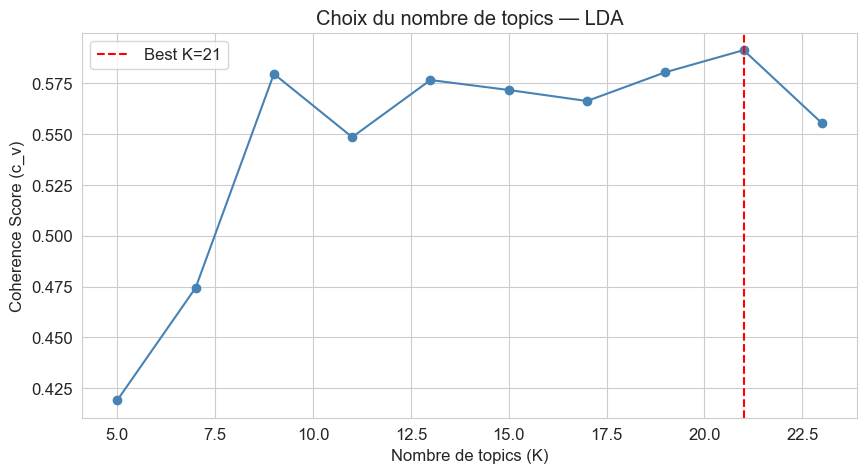


Meilleur K = 21 (c_v = 0.5913)


In [11]:
if len(df) > 0:
    K_range = range(5, 25, 2)  
    coherence_scores = []
    
    for k in K_range:
        lda = models.LdaMulticore(
            corpus_bow, num_topics=k, id2word=dictionary,
            passes=10, workers=2, random_state=42
        )
        cm = CoherenceModel(model=lda, texts=token_lists, 
                            dictionary=dictionary, coherence='c_v')
        score = cm.get_coherence()
        coherence_scores.append(score)
        print(f"  K={k:2d}  →  c_v = {score:.4f}")
    
    # Plot
    plt.figure(figsize=(10, 5))
    plt.plot(list(K_range), coherence_scores, 'o-', color='steelblue')
    plt.xlabel('Number of topics (K)')
    plt.ylabel('Coherence Score (c_v)')
    plt.title('Number of topics — LDA')
    best_k = list(K_range)[np.argmax(coherence_scores)]
    plt.axvline(best_k, color='red', ls='--', label=f'Best K={best_k}')
    plt.legend()
    plt.savefig('lda_coherence.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"\nBest K = {best_k} (c_v = {max(coherence_scores):.4f})")

In [12]:
if len(df) > 0:
    N_TOPICS = best_k  
    
    lda_model = models.LdaMulticore(
        corpus_bow, num_topics=N_TOPICS, id2word=dictionary,
        passes=20, workers=2, random_state=42
    )
    
    print(f"LDA entraîné avec K={N_TOPICS} topics\n")
    for idx, topic in lda_model.print_topics(num_words=10):
        print(f"Topic {idx:2d}: {topic}")

LDA entraîné avec K=21 topics

Topic  6: 0.013*"union" + 0.013*"démocratie" + 0.012*"vie" + 0.012*"lille" + 0.011*"nouveau" + 0.010*"association" + 0.009*"ecologie" + 0.009*"citoyen" + 0.009*"société" + 0.009*"écologie"
Topic 16: 0.027*"union" + 0.014*"udf" + 0.013*"dimanche" + 0.013*"opposition" + 0.013*"nouveau" + 0.011*"rpr" + 0.011*"besoin" + 0.011*"réforme" + 0.011*"changement" + 0.011*"changer"
Topic 13: 0.009*"emploi" + 0.008*"social" + 0.008*"union" + 0.007*"monsieur" + 0.007*"confiance" + 0.007*"nouveau" + 0.007*"ensemble" + 0.007*"avenir" + 0.006*"udf" + 0.006*"rpr"
Topic  3: 0.032*"front" + 0.021*"force" + 0.016*"avenir" + 0.016*"udf" + 0.016*"rpr" + 0.012*"populaire" + 0.011*"vif" + 0.011*"confiance" + 0.011*"conviction" + 0.011*"électeur"
Topic 15: 0.023*"travailleur" + 0.017*"parti" + 0.011*"salaire" + 0.009*"gouvernement" + 0.008*"droit" + 0.008*"social" + 0.007*"public" + 0.007*"ouvrier" + 0.007*"école" + 0.007*"travail"
Topic  0: 0.017*"front" + 0.016*"immigration" + 0

Manual labelling of the topics

Viz

In [13]:
if len(df) > 0:
        import pyLDAvis
        import pyLDAvis.gensim_models
        
        vis = pyLDAvis.gensim_models.prepare(lda_model, corpus_bow, dictionary)
        pyLDAvis.display(vis)

dominant topic to each doc

In [14]:
if len(df) > 0:
    def get_dominant_topic(bow):
        topic_dist = lda_model.get_document_topics(bow, minimum_probability=0)
        return max(topic_dist, key=lambda x: x[1])
    
    results = [get_dominant_topic(bow) for bow in corpus_bow]
    df['lda_topic'] = [r[0] for r in results]
    df['lda_topic_prob'] = [r[1] for r in results]
    
    print("Distribution des topics dominants :")
    print(df['lda_topic'].value_counts().sort_index())

Distribution des topics dominants :
lda_topic
0       75
1      445
2      515
3      517
4      466
5      863
6       45
7      234
8      182
9      519
10     338
11    1849
12     621
13     703
14     192
15     180
16      40
17     312
18     159
19      38
20     332
Name: count, dtype: int64


## 1.2 - BERTopic

## BERTopic — Embedding-based Topic Modeling

Unlike LDA and NMF, which rely on word frequency representations (BoW or TF-IDF), **BERTopic** (Grootendorst, 2022) operates on dense document embeddings produced by pre-trained transformer models. As described in the course (slides 23–29), BERTopic follows a four-step pipeline:

1. **Embed documents** using a sentence-transformer model. We use `paraphrase-multilingual-MiniLM-L12-v2`, a lightweight multilingual model that handles French well without requiring a GPU. A heavier French-specific alternative (`sentence-camembert-large`) is available but was not necessary for this corpus size.

2. **Reduce dimensionality** with UMAP (from 384 dimensions to 5), preserving local semantic structure while making clustering tractable. We set `min_dist=0.0` and `metric='cosine'` to favor tight, well-separated clusters in the reduced space.

3. **Cluster documents** with HDBSCAN, a density-based algorithm (slide 27–28) that automatically determines the number of clusters and allows outliers (topic -1). We set `min_cluster_size=10` to avoid micro-clusters on our 12,500-document corpus. Unlike K-Means, HDBSCAN does not require specifying K in advance and can discover irregular cluster shapes.

4. **Extract topic representations** using a class-based TF-IDF (c-TF-IDF, slide 29): all documents in a cluster are concatenated into a single "topic-document", and TF-IDF is computed at the topic level to find the most distinctive words. We pass a French `CountVectorizer` with stopwords and bigrams to improve topic label quality.

A key difference from LDA/NMF is that BERTopic feeds **raw cleaned text** (not lemmatised tokens) into the embedding model, since transformers capture morphological and contextual information internally. The `CountVectorizer` is only used for the final topic labelling step, not for the clustering itself.

In [15]:
from bertopic import BERTopic
from sentence_transformers import SentenceTransformer

if len(df) > 0:
    # French embedding model (multilingual, small, good for clustering)
    embedding_model = SentenceTransformer("paraphrase-multilingual-MiniLM-L12-v2")
    
    docs = df['text_clean'].tolist()
    print("Computing embeddings...")
    embeddings = embedding_model.encode(docs, show_progress_bar=True)

Computing embeddings...


Batches:   0%|          | 0/270 [00:00<?, ?it/s]

In [16]:
if len(df) > 0:
    # Train BERTopic
    from umap import UMAP
    from hdbscan import HDBSCAN
    from sklearn.feature_extraction.text import CountVectorizer
    
    # UMAP for dimensionality reduction
    umap_model = UMAP(
        n_neighbors=15, n_components=5,
        min_dist=0.0, metric='cosine', random_state=42
    )
    
    # HDBSCAN for clustering
    hdbscan_model = HDBSCAN(
        min_cluster_size=10,     # adjust based on corpus size
        min_samples=5,
        metric='euclidean',
        prediction_data=True
    )
    
    # French vectorizer for topic representations
    vectorizer = CountVectorizer(
        stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
        min_df=3, max_df=0.6,
        ngram_range=(1, 2)  # unigrams + bigrams
    )
    
    topic_model = BERTopic(
        embedding_model=embedding_model,
        umap_model=umap_model,
        hdbscan_model=hdbscan_model,
        vectorizer_model=vectorizer,
        top_n_words=10,
        verbose=True
    )
    
    topics, probs = topic_model.fit_transform(docs, embeddings)
    
    print(f"\nTopics found: {len(set(topics)) - 1}")  # -1 for topic -1 (outliers)
    print(f"Outlier documents (topic -1): {topics.count(-1)} ({topics.count(-1)/len(topics)*100:.0f}%)")

2026-03-16 18:45:10,266 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2026-03-16 18:45:32,289 - BERTopic - Dimensionality - Completed ✓
2026-03-16 18:45:32,295 - BERTopic - Cluster - Start clustering the reduced embeddings
2026-03-16 18:45:32,486 - BERTopic - Cluster - Completed ✓
2026-03-16 18:45:32,496 - BERTopic - Representation - Fine-tuning topics using representation models.
2026-03-16 18:45:35,827 - BERTopic - Representation - Completed ✓



Topics found: 143
Outlier documents (topic -1): 3017 (35%)


In [17]:
if len(df) > 0:
    # Show topics
    topic_info = topic_model.get_topic_info()
    print(topic_info.head(20).to_string())
    
    # Viz topics
    fig = topic_model.visualize_barchart(top_n_topics=12, n_words=8)
    fig.write_html("bertopic_barchart.html")
    fig.show()

    Topic  Count                                                           Name                                                                                                                                                         Representation                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                  

manual labeling of the topics 

dominant topic to each doc

In [18]:
import numpy as np

if len(df) > 0:
    df['bert_topic'] = topics
    df['bert_topic_prob'] = [
        float(p) if isinstance(p, (int, float, np.floating)) else max(p)
        for p in probs
    ]

# 1.3 - NMF 

## NMF — Non-negative Matrix Factorisation

**NMF** (Lee & Seung, 1999) decomposes the document-term matrix **V** into two non-negative matrices: **W** (document × topic, the activation matrix) and **H** (topic × word, the dictionary matrix), such that V ≈ W × H (slide 15). Unlike LDA, NMF has no probabilistic assumptions — it minimises a reconstruction error under non-negativity constraints, which naturally produces sparse, part-based representations that tend to be more interpretable (slide 17: "sharper, more localized topics").

As noted in the course, NMF operates on any non-negative matrix but works best with **TF-IDF** features rather than raw counts (slide 16). TF-IDF downweights terms that appear in many documents, which complements NMF's sparsity bias by ensuring topics are driven by discriminative vocabulary rather than common filler words. We cap the vocabulary at 10,000 features and include bigrams (`ngram_range=(1,2)`) to capture multi-word political expressions (*extrême droite*, *parti socialiste*, *service public*) that would be lost as separate unigrams.

We set K equal to the same number of topics as LDA to enable direct comparison of topic quality across methods. The **W matrix** gives each document's topic mixture (analogous to θ in LDA), from which we extract the dominant topic per document. The **H matrix** gives each topic's word distribution, from which we extract the top words for interpretation and coherence evaluation.

As with LDA, the number of topics K is a hyperparameter that must be optimised. Following the professor's lab methodology, we train NMF for several values of K and evaluate each using three coherence metrics (u_mass, c_v, c_npmi). Since these metrics have different scales, we apply min-max normalisation to compare their relative trends on the same plot

In [ ]:
# ============================================================
# NMF — Topic number selection (multi-metric coherence curve)
# ============================================================
from sklearn.decomposition import NMF
from sklearn.feature_extraction.text import TfidfVectorizer
from gensim.models.coherencemodel import CoherenceModel

import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# TF-IDF on cleaned texts (shared with final NMF model)
tfidf = TfidfVectorizer(
    max_features=10000, min_df=5, max_df=0.6,
    stop_words=list(nlp.Defaults.stop_words | CUSTOM_STOPWORDS),
    ngram_range=(1, 2)
)
tfidf_matrix = tfidf.fit_transform(df['text_clean'])
feature_names = tfidf.get_feature_names_out()

# Coherence sweep
topic_range = [5, 7, 9, 11, 13, 15]
coherence_metrics = ['u_mass', 'c_v', 'c_npmi']
results_nmf = {m: {} for m in coherence_metrics}

for k in topic_range:
    nmf_k = NMF(n_components=k, random_state=42, max_iter=500)
    W_k = nmf_k.fit_transform(tfidf_matrix)
    
    # Extract top words per topic
    topics_k = []
    for topic in nmf_k.components_:
        top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
        topics_k.append(top_words)
    
    for met in coherence_metrics:
        cm = CoherenceModel(topics=topics_k, texts=token_lists,
                            dictionary=dictionary, coherence=met)
        score = cm.get_coherence()
        results_nmf[met][k] = score
        print(f"NMF K={k} — {met}: {score:.4f}")

# Normalised plot
plt.figure(figsize=(10, 6))
for met in coherence_metrics:
    ks = sorted(results_nmf[met].keys())
    scores = np.array([results_nmf[met][k] for k in ks])
    norm_scores = (scores - scores.min()) / (scores.max() - scores.min() + 1e-10)
    plt.plot(ks, norm_scores, marker='o', label=met)

plt.xlabel("Number of topics (K)")
plt.ylabel("Normalised coherence score")
plt.title("NMF coherence — multi-metric comparison")
plt.legend()
plt.grid(True)
plt.savefig('coherence_nmf_multi.png', dpi=150, bbox_inches='tight')
plt.show()

# Select best K based on c_v
best_k_nmf = max(results_nmf['c_v'], key=results_nmf['c_v'].get)
print(f"\nBest K (c_v): {best_k_nmf} (c_v = {results_nmf['c_v'][best_k_nmf]:.4f})")

NMF K=5 — u_mass: -2.5519


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

NMF K=5 — c_v: 0.7137


huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The current process just got forked, after parallelism has already been used. Disabling parallelism to avoid deadlocks...
To disable this warning, you can either:
	- Avoid using `tokenizers` before the fork if possible
	- Explicitly set the environment variable TOKENIZERS_PARALLELISM=(true | false)
huggingface/tokenizers: The 

We train the final NMF model using the K selected above. As in the professor's lab, we extract the **W matrix** (document-topic proportions) and the **H matrix** (topic-word weights), assign a dominant topic to each document, and cross-tabulate with political families

In [ ]:
# ============================================================
# NMF — Final model with optimal K
# ============================================================
N_TOPICS_NMF = best_k_nmf  # or override manually

nmf_model = NMF(n_components=N_TOPICS_NMF, random_state=42, max_iter=500)
W = nmf_model.fit_transform(tfidf_matrix)  # doc-topic matrix
H = nmf_model.components_                   # topic-word matrix

print(f"NMF with K={N_TOPICS_NMF} topics\n")
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    print(f"Topic {i:2d}: {', '.join(top_words)}")

# Dominant topic per document
df['nmf_topic'] = W.argmax(axis=1)

# Heatmap NMF × political family
ct_nmf = pd.crosstab(df['famille'], df['nmf_topic'], normalize='index')
plt.figure(figsize=(12, 6))
sns.heatmap(ct_nmf, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
plt.title('NMF topic distribution by political family')
plt.xlabel('NMF Topic')
plt.savefig('nmf_topics_famille.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
# Manuel labeling of the topics

# Dominant topic per document
df['nmf_topic'] = W.argmax(axis=1)

# # Heatmap NMF × political family
# ct_nmf = pd.crosstab(df['famille'], df['nmf_topic'], normalize='index')
# plt.figure(figsize=(12, 6))
# sns.heatmap(ct_nmf, annot=True, fmt='.2f', cmap='YlOrRd', linewidths=0.5)
# plt.title('NMF topic distribution by political family')
# plt.xlabel('NMF Topic')
# plt.savefig('nmf_topics_famille.png', dpi=150, bbox_inches='tight')
# plt.show()

# 1.4 - Quantitative comparison of the models

To compare LDA, NMF, and BERTopic on equal footing, we evaluate all three using the same coherence metrics computed on the same gensim dictionary and tokenised corpus. We report **c_v** (Röder et al., 2015), which correlates best with human coherence judgments, and **u_mass**, which is computed directly from document co-occurrence statistics (slides 19–20). For BERTopic, topic words are filtered to only include terms present in the gensim dictionary, since BERTopic's c-TF-IDF may produce bigrams or rare tokens absent from the BoW vocabulary. Note that coherence metrics favour BoW-based methods by design — they measure lexical co-occurrence, not semantic similarity — so a lower BERTopic score does not necessarily indicate worse topics, but rather a different kind of topic structure

In [ ]:
import os
os.environ["TOKENIZERS_PARALLELISM"] = "false"

# ============================================================
# COMPARATIVE TABLE: LDA vs NMF vs BERTopic
# ============================================================
from gensim.models import CoherenceModel

results = []

# --- LDA coherence ---
for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(model=lda_model, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'LDA', 'Metric': metric, 'Score': cm.get_coherence()})

# --- NMF coherence (extract top words from H matrix) ---
nmf_topics_words = []
for i, topic in enumerate(H):
    top_words = [feature_names[j] for j in topic.argsort()[-10:][::-1]]
    nmf_topics_words.append(top_words)

for metric in ['c_v', 'u_mass']:
    cm = CoherenceModel(topics=nmf_topics_words, texts=token_lists,
                        dictionary=dictionary, coherence=metric)
    results.append({'Model': 'NMF', 'Metric': metric, 'Score': cm.get_coherence()})

# --- BERTopic coherence (filter words to those in gensim dictionary) ---
bert_topics_words = []
dict_tokens = set(dictionary.values())

for topic_id in range(len(set(topics)) - 1):
    words = [w for w, _ in topic_model.get_topic(topic_id)]
    words_filtered = [w for w in words if w in dict_tokens][:10]
    if len(words_filtered) >= 3:  # minimum 3 words for coherence
        bert_topics_words.append(words_filtered)

print(f"BERTopic topics with enough words in dictionary: {len(bert_topics_words)}")

for metric in ['c_v', 'u_mass']:
    try:
        cm = CoherenceModel(topics=bert_topics_words, texts=token_lists,
                            dictionary=dictionary, coherence=metric)
        score = cm.get_coherence()
        print(f"BERTopic — {metric}: {score:.4f}")
    except Exception as e:
        print(f"BERTopic — {metric}: Error {e}")

df_comparison = pd.DataFrame(results)
print(df_comparison.pivot(index='Model', columns='Metric', values='Score').round(4))

# Quantitative summary
print(f"""
╔═══════════════╦══════════════════════╦═══════════════════╦══════════════════════╗
║ Aspect        ║ LDA                  ║ NMF               ║ BERTopic             ║
╠═══════════════╬══════════════════════╬═══════════════════╬══════════════════════╣
║ Input         ║ BoW (counts)         ║ TF-IDF            ║ SBERT embeddings     ║
║ # Topics      ║ {N_TOPICS} (fixed)           ║ {N_TOPICS} (fixed)          ║ {len(set(topics))-1} (auto HDBSCAN)   ║
║ Outliers      ║ None                 ║ None              ║ {topics.count(-1)} docs (topic -1) ║
║ Interpretab.  ║ Diffuse              ║ Sharper           ║ Party templates      ║
╚═══════════════╩══════════════════════╩═══════════════════╩══════════════════════╝
""")

# 2 - Qualitative analysis, metadata x topics cross analysis

## 2.1 - Temporal evolution of topics 

## 2.2 - Topics and political family

### Topic specialization by party - over/under representation

## 2.3 - Topics by election / party 
See if things changed 

## 2.4 - Topics by candidate characteristics

## Conclusion